In [70]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import  warnings
warnings.filterwarnings("ignore")

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from catboost import CatBoostRegressor
from xgboost import XGBRegressor


In [71]:
df = pd.read_csv("data/modified_data.csv")
df.head()

,Unnamed: 0,gender,race/ethnicity,parental level of education,lunch,test preparation course,Total_score
0,0,female,group B,bachelor's degree,standard,none,72.666667
1,1,female,group C,some college,standard,completed,82.333333
2,2,female,group B,master's degree,standard,none,92.666667
3,3,male,group A,associate's degree,free/reduced,none,49.333333
4,4,male,group C,some college,standard,none,76.333333


# Seperate dependent and Independent Feature

In [72]:
x = df.drop(['Total_score'], axis=1)
y = df['Total_score']

In [73]:
x

,Unnamed: 0,gender,race/ethnicity,parental level of education,lunch,test preparation course
0,0,female,group B,bachelor's degree,standard,none
1,1,female,group C,some college,standard,completed
2,2,female,group B,master's degree,standard,none
3,3,male,group A,associate's degree,free/reduced,none
4,4,male,group C,some college,standard,none
...,...,...,...,...,...,...
995,995,female,group E,master's degree,standard,completed
996,996,male,group C,high school,free/reduced,none
997,997,female,group C,high school,free/reduced,completed
998,998,female,group D,some college,standard,completed


In [74]:
y

0      72.666667
1      82.333333
2      92.666667
3      49.333333
4      76.333333
         ...    
995    94.000000
996    57.333333
997    65.000000
998    74.333333
999    83.000000
Name: Total_score, Length: 1000, dtype: float64

In [75]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

num_feature = x.select_dtypes(exclude='object').columns
cat_feature = x.select_dtypes(include='object').columns

print(num_feature)
print(cat_feature)

Index(['Unnamed: 0'], dtype='object')
Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course'],
      dtype='object')


In [76]:
x= x.drop(columns=num_feature)

In [77]:
x.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course
0,female,group B,bachelor's degree,standard,none
1,female,group C,some college,standard,completed
2,female,group B,master's degree,standard,none
3,male,group A,associate's degree,free/reduced,none
4,male,group C,some college,standard,none


In [78]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.25)

In [79]:
x_train

,gender,race/ethnicity,parental level of education,lunch,test preparation course
798,male,group E,some college,standard,none
578,female,group B,some college,free/reduced,completed
182,female,group E,high school,standard,none
572,female,group C,some college,standard,none
617,male,group D,bachelor's degree,standard,none
...,...,...,...,...,...
502,male,group C,some college,free/reduced,none
664,male,group D,associate's degree,standard,none
823,female,group B,high school,free/reduced,none
983,female,group A,some college,standard,completed


In [80]:
ohe = OneHotEncoder()
x_train = ohe.fit_transform(x_train)
x_test = ohe.transform(x_test)

In [81]:
print(x_train[:5].toarray())

[[0. 1. 0. 0. 0. 0. 1. 0. 0. 0. 0. 1. 0. 1. 0. 1.]
 [1. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 1. 1. 0. 1. 0.]
 [1. 0. 0. 0. 0. 0. 1. 0. 0. 1. 0. 0. 0. 1. 0. 1.]
 [1. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 1. 0. 1. 0. 1.]
 [0. 1. 0. 0. 0. 1. 0. 0. 1. 0. 0. 0. 0. 1. 0. 1.]]


In [82]:
x_train.shape

(750, 16)

# Create an Evaluate Function to give all metrics after Model Training

In [83]:
def evaluate_metrics(true, predicted):
    print("="*50)
    print("r2_score: ", r2_score(true, predicted))
    print("="*50)
    print("mean squared error: ", mean_squared_error(true, predicted))
    print("=" * 50)
    print("root mean squared error: ", np.sqrt(mean_squared_error(true, predicted)))
    print("=" * 50)
    print("mean absolute error: ", mean_absolute_error(true, predicted))
    print("=" * 50)

In [84]:
models = {
    'LinearRegression' : LinearRegression(),
    'Lasso' : Lasso(),
    'Ridge' : Ridge(),
    'RandomForestRegressor' : RandomForestRegressor(),
    'KNeighborsRegressor' : KNeighborsRegressor(),
    'DecisionTreeRegressor' : DecisionTreeRegressor(),
    'XGBRegressor' : XGBRegressor(),
    'CatBoostRegressor' : CatBoostRegressor(verbose=False),
    'AdaBoostRegressor' : AdaBoostRegressor()
}

for i in models.keys():
    model = models[i]
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    print("Model: ", i)
    evaluate_metrics(y_test, y_pred)

Model:  LinearRegression
r2_score:  0.0732981375150864
mean squared error:  157.93437333322007
root mean squared error:  12.567194330208316
mean absolute error:  10.124218514838118
Model:  Lasso
r2_score:  0.06940285878926189
mean squared error:  158.5982312895122
root mean squared error:  12.593578970630716
mean absolute error:  10.15384622899984
Model:  Ridge
r2_score:  0.07424921276601948
mean squared error:  157.7722850933777
root mean squared error:  12.560743811310607
mean absolute error:  10.119835849226137
Model:  RandomForestRegressor
r2_score:  -0.18256258197859565
mean squared error:  201.53977009530908
root mean squared error:  14.196470339324106
mean absolute error:  11.139082867102353
Model:  KNeighborsRegressor
r2_score:  -0.13227529321608333
mean squared error:  192.9694933333334
root mean squared error:  13.891345987100507
mean absolute error:  11.194133333333335
Model:  DecisionTreeRegressor
r2_score:  -0.2726173504199718
mean squared error:  216.88747143834865
root m

In [ ]:
model = LinearRegression()
model.fit(x_train, y_train)
y_pred = model.predict(x_test)
pred_diff = pd.DataFrame({'Actual value': y_test, 'predicted value': y_pred, 'Difference' : y_test-y_pred})
pred_diff


,Actual value,predicted value,Difference
109,68.666667,63.772975,4.893692
945,57.666667,70.217454,-12.550787
444,78.000000,48.670870,29.329130
149,97.666667,70.076878,27.589788
112,51.333333,63.758287,-12.424953
...,...,...,...
785,42.333333,72.196318,-29.862985
262,48.333333,55.130037,-6.796704
579,60.666667,77.365161,-16.698495
241,82.000000,77.491829,4.508171


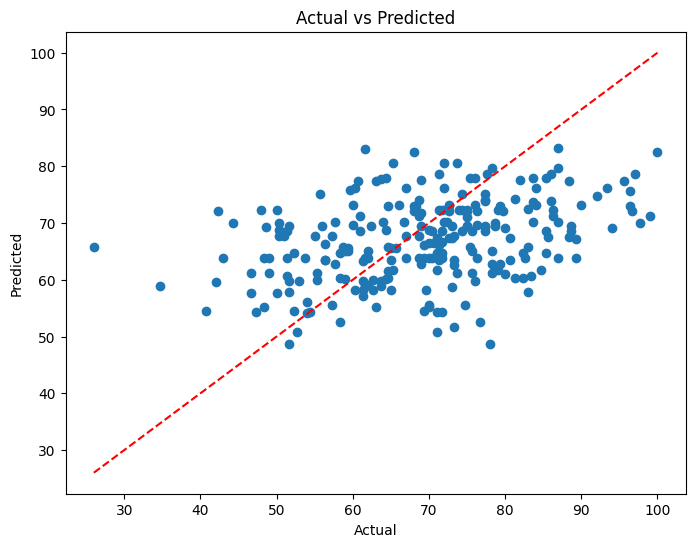

In [93]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred)

plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()


In [94]:
print("Actual mean:", y_test.mean())
print("Predicted mean:", y_pred.mean())

print("Actual std:", y_test.std())
print("Predicted std:", y_pred.std())


Actual mean: 69.264
Predicted mean: 66.95439406670141
Actual std: 13.080930662149074
Predicted std: 7.196740920542737


## Observation:
1) Here we tried to predict average score considering only the demographic feature, and its pretty obvious that you will get a large error if you try to predict the score only based on demographic feature. There may also be possibility that there are two students both female both group B with high school studies and with standard lunch but gets completly different score
2) If we want more correlation we can keep one subject score as target and use scores of other two subject as feature which will give us a higher relation on the score of the target

In [95]:
df = pd.read_csv('data/StudentsPerformance.csv')
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [96]:
df["parental level of education"] = df["parental level of education"].replace(
    "some high school", "high school"
)


In [97]:
x = df.drop(columns='math score')
y = df['math score']

In [98]:
x

,gender,race/ethnicity,parental level of education,lunch,test preparation course,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,74
1,female,group C,some college,standard,completed,90,88
2,female,group B,master's degree,standard,none,95,93
3,male,group A,associate's degree,free/reduced,none,57,44
4,male,group C,some college,standard,none,78,75
...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,99,95
996,male,group C,high school,free/reduced,none,55,55
997,female,group C,high school,free/reduced,completed,71,65
998,female,group D,some college,standard,completed,78,77


In [99]:
y

0      72
1      69
2      90
3      47
4      76
       ..
995    88
996    62
997    59
998    68
999    77
Name: math score, Length: 1000, dtype: int64

In [100]:
x_train, x_test, y_train,y_test = train_test_split(x,y, test_size=0.25, random_state= 42)

In [104]:
num_feature = x.select_dtypes(exclude='object').columns
cat_feature = x.select_dtypes(include='object').columns

preprocessor = ColumnTransformer(
    [
        ('StandardScaler', StandardScaler(), num_feature),
        ('OneHotEncoder', OneHotEncoder(), cat_feature)
    ], remainder= 'passthrough'
)

x_train = preprocessor.fit_transform(x_train)
x_test = preprocessor.transform(x_test)

In [106]:
models = {
    "LinearRegression": LinearRegression(),
    "Lasso": Lasso(),
    "Ridge": Ridge(),
    "RandomForestRegressor": RandomForestRegressor(),
    "KNeighborsRegressor": KNeighborsRegressor(),
    "DecisionTreeRegressor": DecisionTreeRegressor(),
    "XGBRegressor": XGBRegressor(),
    "CatBoostRegressor": CatBoostRegressor(verbose=False),
    "AdaBoostRegressor": AdaBoostRegressor(),
}

for i in models.keys():
    model = models[i]
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    print("Model: ", i)
    evaluate_metrics(y_test, y_pred)


Model:  LinearRegression
r2_score:  0.8779568250123724
mean squared error:  30.025512982030907
root mean squared error:  5.479554086057633
mean absolute error:  4.334162431988379
Model:  Lasso
r2_score:  0.8202484185317581
mean squared error:  44.22314843466199
root mean squared error:  6.650048754307143
mean absolute error:  5.218405738075968
Model:  Ridge
r2_score:  0.8781206659162256
mean squared error:  29.985204237308945
root mean squared error:  5.475874746313044
mean absolute error:  4.331435987806164
Model:  RandomForestRegressor
r2_score:  0.8465853101171648
mean squared error:  37.74364902566894
root mean squared error:  6.143586007021383
mean absolute error:  4.765327238095239
Model:  KNeighborsRegressor
r2_score:  0.7949004066665188
mean squared error:  50.459360000000004
root mean squared error:  7.1034752058411526
mean absolute error:  5.6456
Model:  DecisionTreeRegressor
r2_score:  0.7617465270499798
mean squared error:  58.616
root mean squared error:  7.656108672164992

In [107]:
model = LinearRegression()
model.fit(x_train, y_train)
y_pred = model.predict(x_test)
pred_diff = pd.DataFrame(
    {"Actual value": y_test, "predicted value": y_pred, "Difference": y_test - y_pred}
)
pred_diff


,Actual value,predicted value,Difference
521,91,76.420431,14.579569
737,53,58.835943,-5.835943
740,80,76.906651,3.093349
660,74,76.768207,-2.768207
411,84,87.446861,-3.446861
...,...,...,...
109,70,64.165775,5.834225
430,64,63.166849,0.833151
77,80,82.711995,-2.711995
84,42,39.287192,2.712808


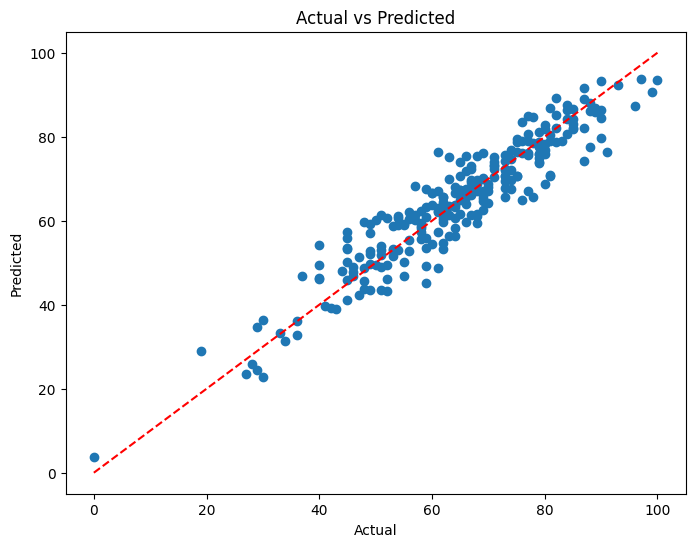

In [108]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred)

plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()


In [109]:
print("Actual mean:", y_test.mean())
print("Predicted mean:", y_pred.mean())

print("Actual std:", y_test.std())
print("Predicted std:", y_pred.std())


Actual mean: 64.548
Predicted mean: 64.59988007470992
Actual std: 15.716607234765636
Predicted std: 14.881695485635719


## Observation 
We can see a much better model when we keep 2 scores as feature